# FlyRank Search Content Opportunity Scoring

## Capstone Research Question

Can observed search-performance signals be used to rank pages by content-review opportunity?

## Decision Supported

Which pages should a content team review first?

## Lane

Refresh / Content Opportunity Scoring

## Output

A ranked content-review list with evidence-based reason codes and recommended actions.

## Important Framing

This project is a decision-support analysis. It measures patterns in the available FlyRank data and does not claim to reveal Google's ranking algorithm or establish causal effects.

## Abstract

This capstone asks whether observed search-performance signals can be used to rank pages by content-review opportunity. Using an anonymized FlyRank starter dataset, the analysis constructs a transparent prototype opportunity label based on recent impression decline and evaluates a Logistic Regression model against a majority-class baseline. On the held-out test set, the Logistic Regression model achieved 0.453 precision, 0.663 recall, 0.538 F1, 0.671 ROC-AUC, and 0.467 PR-AUC, while the majority baseline identified no opportunities. The model was then used to generate a ranked review queue with opportunity scores and human-readable reason codes. These results are prototype decision-support evidence and do not establish causal effects, reveal Google's ranking algorithm, or guarantee that changing a recommended page will improve performance.

## Introduction / Problem Statement

Content teams need a repeatable way to decide which pages should be reviewed first when search performance changes. Reviewing every page equally is inefficient, while relying on a single metric can miss pages that show multiple signals of potential opportunity.

This project asks whether observed search-performance signals can be combined into a transparent ranking of pages by content-review opportunity. The intended decision is to help a content team prioritize pages for review, monitoring, or further investigation.

The output is a ranked review queue with an opportunity score, supporting reason codes, and an action category. This is decision-support evidence rather than a claim about Google's ranking algorithm or a guarantee that editing a page will improve its future performance.


In [43]:
# Capstone environment

import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt

print("Environment ready.")
print("DuckDB:", duckdb.__version__)
print("Pandas:", pd.__version__)

Environment ready.
DuckDB: 1.3.2
Pandas: 2.2.3


In [44]:
# Load starter dataset for capstone development

url = "https://raw.githubusercontent.com/zeeofficial01/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

Rows: 30000
Columns: 44

Column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [45]:
# Inspect key variables for the opportunity-scoring analysis

key_cols = [
    "content_id",
    "content_type",
    "main_intent",
    "search_volume",
    "competition",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "trend_direction",
    "trend_pct"
]

display(df[key_cols].head(10))

,content_id,content_type,main_intent,search_volume,competition,word_count,content_age_days,days_since_last_update,impressions_90d,clicks_90d,sessions_90d,impressions_last_30d,clicks_last_30d,sessions_last_30d,ctr,avg_position,engagement_rate,trend_direction,trend_pct
0,content_304f48230142,keyword article,transactional,10.0,0.67,3221.0,187,20,3803,29,17,578,2,2,0.76,10.6,5.88,down,-41.4
1,content_a1fb4e703a9e,keyword article,informational,90.0,0.01,2481.0,445,25,15320,7,9,2501,2,3,0.05,20.3,0.00,down,-57.7
2,content_9aa793d4d895,keyword article,informational,0.0,0.00,3515.0,141,20,12581,11,11,2382,1,1,0.09,36.5,0.00,down,-60.9
3,content_331d6c4de07b,keyword article,commercial,10.0,0.00,NaN,463,22,11751,58,78,3626,22,35,0.49,6.2,1.28,stable,-13.8
4,content_d99b7a2d90ca,keyword article,informational,0.0,0.00,2803.0,263,14,19140,24,145,4211,10,14,0.13,44.0,0.00,down,-34.7
5,content_d4084a4bc775,keyword article,transactional,720.0,1.00,3080.0,147,20,3970,1,5,617,0,4,0.03,8.5,0.00,down,-38.9
6,content_9a34b442b552,keyword article,informational,0.0,0.00,3059.0,90,20,20,0,1,1,0,0,0.00,7.0,0.00,down,-92.3
7,content_a63219c6e95a,keyword article,commercial,590.0,0.44,NaN,445,22,1724,1,28,636,1,24,0.06,21.2,3.57,stable,0.6
8,content_5e6c160719bc,keyword article,informational,0.0,0.00,3807.0,90,20,32574,29,68,5696,9,36,0.09,46.0,5.88,down,-58.8
9,content_c27558df2b0c,keyword article,informational,0.0,0.00,NaN,257,104,1240,2,3,252,0,0,0.16,4.9,0.00,down,-29.2


In [46]:
# Check missing values and basic data types

check = pd.DataFrame({
    "dtype": df[key_cols].dtypes.astype(str),
    "missing": df[key_cols].isna().sum(),
    "unique_values": df[key_cols].nunique()
})

display(check)

,dtype,missing,unique_values
content_id,object,0,30000
content_type,object,0,3
main_intent,object,2374,4
search_volume,float64,2468,41
competition,float64,2468,101
word_count,float64,7699,5476
content_age_days,int64,0,225
days_since_last_update,int64,0,57
impressions_90d,int64,0,9438
clicks_90d,int64,0,477


In [47]:
# Explore the main signals we may use for content-review opportunity

print("Trend distribution:")
print(df["trend_direction"].value_counts(dropna=False))

print("\nTrend percentage summary:")
print(df["trend_pct"].describe())

print("\nAverage position summary:")
print(df["avg_position"].describe())

print("\nCTR summary:")
print(df["ctr"].describe())

print("\nDays since last update:")
print(df["days_since_last_update"].describe())

Trend distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Trend percentage summary:
count    26612.000000
mean        -4.785969
std        473.861780
min       -100.000000
25%        -62.600000
50%        -33.500000
75%          0.000000
max      44900.000000
Name: trend_pct, dtype: float64

Average position summary:
count    30000.00000
mean        16.34238
std         15.21679
min          0.00000
25%          6.20000
50%         10.80000
75%         22.30000
max        245.00000
Name: avg_position, dtype: float64

CTR summary:
count    30000.000000
mean         0.510733
std          3.279162
min          0.000000
25%          0.000000
50%          0.070000
75%          0.290000
max        100.000000
Name: ctr, dtype: float64

Days since last update:
count    30000.000000
mean        46.098300
std         42.078709
min          1.000000
25%         20.000000
50%         20.000000
75%        104.00000

In [48]:
# Compare key performance signals by observed trend direction

trend_summary = (
    df.groupby("trend_direction")
      .agg(
          pages=("content_id", "count"),
          avg_impressions_90d=("impressions_90d", "mean"),
          avg_clicks_90d=("clicks_90d", "mean"),
          avg_ctr=("ctr", "mean"),
          avg_position=("avg_position", "mean"),
          avg_days_since_update=("days_since_last_update", "mean"),
          avg_trend_pct=("trend_pct", "mean")
      )
      .sort_values("pages", ascending=False)
)

display(trend_summary)

,pages,avg_impressions_90d,avg_clicks_90d,avg_ctr,avg_position,avg_days_since_update,avg_trend_pct
trend_direction,,,,,,,
down,16262,4919.097466,13.359242,0.324138,15.936305,49.245788,-58.113830
stable,5962,9213.615230,34.142402,0.517321,16.332623,50.061892,-3.185944
up,4388,4716.081130,13.944394,0.565533,22.512739,43.425706,190.673997
new,2236,164.131038,0.385957,1.296521,9.912433,22.337209,NaN
flat,1152,20.738715,0.055556,1.376753,11.102431,37.453993,NaN


In [49]:
# Create a transparent prototype label for content-review opportunity

df["recent_impression_change_pct"] = np.where(
    df["impressions_prev_30d"] > 0,
    ((df["impressions_last_30d"] - df["impressions_prev_30d"])
     / df["impressions_prev_30d"]) * 100,
    np.nan
)

# Use the median decline among pages with a measurable decline
declining = df.loc[
    (df["impressions_prev_30d"] > 0) &
    (df["impressions_last_30d"] < df["impressions_prev_30d"]),
    "recent_impression_change_pct"
]

decline_threshold = declining.median()

df["review_opportunity"] = (
    (df["impressions_90d"] > 0) &
    (df["recent_impression_change_pct"] <= decline_threshold)
).astype(int)

print("Decline threshold (%):", round(decline_threshold, 2))
print("\nReview opportunity distribution:")
print(df["review_opportunity"].value_counts())
print("\nOpportunity rate:", round(df["review_opportunity"].mean() * 100, 2), "%")

Decline threshold (%): -48.83

Review opportunity distribution:
review_opportunity
0    20142
1     9858
Name: count, dtype: int64

Opportunity rate: 32.86 %


In [50]:
# Validate the prototype label

label_summary = (
    df.groupby("review_opportunity")
      .agg(
          pages=("content_id", "count"),
          avg_impressions_90d=("impressions_90d", "mean"),
          avg_ctr=("ctr", "mean"),
          avg_position=("avg_position", "mean"),
          avg_days_since_update=("days_since_last_update", "mean"),
          avg_recent_change_pct=("recent_impression_change_pct", "mean")
      )
)

display(label_summary)

,pages,avg_impressions_90d,avg_ctr,avg_position,avg_days_since_update,avg_recent_change_pct
review_opportunity,,,,,,
0,20142,6089.314269,0.600137,16.284048,45.506107,35.586105
1,9858,3384.055691,0.328064,16.461564,47.308278,-73.399041


In [51]:
# Define leakage-aware features

feature_cols = [
    "search_volume",
    "competition",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "char_count_tier",
    "impression_tier",
    "position_tier"
]

X = df[feature_cols].copy()
y = df["review_opportunity"]

print("Features:", len(feature_cols))
print("Rows:", len(X))
print("Target rate:", round(y.mean() * 100, 2), "%")

Features: 18
Rows: 30000
Target rate: 32.86 %


In [52]:
# Create a stratified train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training opportunity rate:", round(y_train.mean() * 100, 2), "%")
print("Test opportunity rate:", round(y_test.mean() * 100, 2), "%")

Training rows: 24000
Test rows: 6000
Training opportunity rate: 32.86 %
Test opportunity rate: 32.87 %


In [53]:
# Baseline + Logistic Regression model

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

numeric_features = [
    "search_volume",
    "competition",
    "word_count",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

categorical_features = [
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "char_count_tier",
    "impression_tier",
    "position_tier"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Baseline and Logistic Regression model trained.")

Baseline and Logistic Regression model trained.


In [54]:
# Evaluate baseline and model on the same untouched test set

baseline_pred = baseline.predict(X_test)
model_pred = model.predict(X_test)
model_prob = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame([
    {
        "model": "Majority baseline",
        "accuracy": accuracy_score(y_test, baseline_pred),
        "precision": precision_score(y_test, baseline_pred, zero_division=0),
        "recall": recall_score(y_test, baseline_pred, zero_division=0),
        "f1": f1_score(y_test, baseline_pred, zero_division=0),
        "roc_auc": np.nan,
        "pr_auc": np.nan
    },
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, model_pred),
        "precision": precision_score(y_test, model_pred, zero_division=0),
        "recall": recall_score(y_test, model_pred, zero_division=0),
        "f1": f1_score(y_test, model_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, model_prob),
        "pr_auc": average_precision_score(y_test, model_prob)
    }
])

display(results.round(3))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Majority baseline,0.671,0.000,0.000,0.000,NaN,NaN
1,Logistic Regression,0.626,0.453,0.663,0.538,0.671,0.467


In [55]:
# Inspect Logistic Regression feature coefficients

feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
}).sort_values("abs_coefficient", ascending=False)

display(feature_importance.head(20))

,feature,coefficient,abs_coefficient
41,categorical__position_tier_top_3,-0.749889,0.749889
33,categorical__impression_tier_excellent,-0.722620,0.722620
28,categorical__word_count_tier_<1000,-0.568254,0.568254
10,categorical__content_type_comparison article,-0.508721,0.508721
12,categorical__content_type_keyword article,0.441349,0.441349
25,categorical__word_count_tier_1000-2000,0.385397,0.385397
3,numeric__content_age_days,-0.377796,0.377796
35,categorical__impression_tier_low,0.307720,0.307720
11,categorical__content_type_feedly article,-0.267393,0.267393
15,categorical__main_intent_navigational,-0.263581,0.263581


In [56]:
# Show the strongest positive and negative signals

print("Top positive signals:")
display(
    feature_importance
    .sort_values("coefficient", ascending=False)
    .head(10)[["feature", "coefficient"]]
)

print("\nTop negative signals:")
display(
    feature_importance
    .sort_values("coefficient", ascending=True)
    .head(10)[["feature", "coefficient"]]
)

Top positive signals:


,feature,coefficient
12,categorical__content_type_keyword article,0.441349
25,categorical__word_count_tier_1000-2000,0.385397
35,categorical__impression_tier_low,0.307720
39,categorical__position_tier_page_3_5,0.242472
36,categorical__impression_tier_moderate,0.240919
18,categorical__age_tier_31-90,0.224166
38,categorical__position_tier_page_1,0.199712
8,numeric__scroll_rate,0.182700
40,categorical__position_tier_striking,0.148478
4,numeric__days_since_last_update,0.089624



Top negative signals:


,feature,coefficient
41,categorical__position_tier_top_3,-0.749889
33,categorical__impression_tier_excellent,-0.722620
28,categorical__word_count_tier_<1000,-0.568254
10,categorical__content_type_comparison article,-0.508721
3,numeric__content_age_days,-0.377796
11,categorical__content_type_feedly article,-0.267393
15,categorical__main_intent_navigational,-0.263581
19,categorical__age_tier_365+,-0.249963
17,categorical__age_tier_181-365,-0.207717
23,categorical__freshness_tier_31-90,-0.206312


In [57]:
# Generate opportunity scores for every page

df["opportunity_score"] = model.predict_proba(df[feature_cols])[:, 1]

ranked = (
    df[
        [
            "content_id",
            "content_type",
            "main_intent",
            "opportunity_score",
            "impressions_90d",
            "ctr",
            "avg_position",
            "content_age_days",
            "days_since_last_update",
            "recent_impression_change_pct",
            "review_opportunity"
        ]
    ]
    .sort_values("opportunity_score", ascending=False)
    .reset_index(drop=True)
)

ranked["priority_rank"] = ranked.index + 1

display(ranked.head(20))

,content_id,content_type,main_intent,opportunity_score,impressions_90d,ctr,avg_position,content_age_days,days_since_last_update,recent_impression_change_pct,review_opportunity,priority_rank
0,content_e02b544b7a9a,keyword article,informational,0.919619,5,0.00,6.2,117,20,NaN,0,1
1,content_a928cb66d230,keyword article,informational,0.919152,128,0.00,4.2,117,20,-78.000000,1,2
2,content_2904469ee111,keyword article,informational,0.917475,12,0.00,12.8,180,28,-100.000000,1,3
3,content_e331f45208a0,keyword article,informational,0.917012,6,0.00,9.2,117,20,NaN,0,4
4,content_94defa9a6783,keyword article,informational,0.915637,19,0.00,6.2,126,20,-71.428571,1,5
5,content_4315e2ea3148,keyword article,informational,0.915272,52,0.00,5.3,138,20,-70.000000,1,6
6,content_0fc4e547c299,keyword article,informational,0.913218,6,0.00,4.5,126,8,NaN,0,7
7,content_5d77d3077984,keyword article,informational,0.912044,68,0.00,3.0,141,20,-72.500000,1,8
8,content_75d5dd728a61,keyword article,transactional,0.904000,1,0.00,7.0,133,8,NaN,0,9
9,content_374e795aab68,keyword article,commercial,0.880228,235,0.85,31.0,181,20,0.000000,0,10


In [58]:
# Create simple, human-readable reason codes

def get_reason_codes(row):
    reasons = []

    if pd.notna(row["recent_impression_change_pct"]) and row["recent_impression_change_pct"] < 0:
        reasons.append("recent impressions declining")

    if row["days_since_last_update"] >= 30:
        reasons.append("not updated recently")

    if row["avg_position"] >= 11:
        reasons.append("weaker average position")

    if row["ctr"] < 0.35:
        reasons.append("lower CTR")

    if row["impressions_90d"] < df["impressions_90d"].median():
        reasons.append("lower impression volume")

    if row["content_age_days"] >= 31:
        reasons.append("established content")

    return "; ".join(reasons[:3]) if reasons else "model signals only"

ranked["reason_codes"] = ranked.apply(get_reason_codes, axis=1)

display(
    ranked[
        [
            "priority_rank",
            "content_id",
            "opportunity_score",
            "reason_codes",
            "recent_impression_change_pct",
            "avg_position",
            "ctr"
        ]
    ].head(20)
)

,priority_rank,content_id,opportunity_score,reason_codes,recent_impression_change_pct,avg_position,ctr
0,1,content_e02b544b7a9a,0.919619,lower CTR; lower impression volume; establishe...,NaN,6.2,0.00
1,2,content_a928cb66d230,0.919152,recent impressions declining; lower CTR; lower...,-78.000000,4.2,0.00
2,3,content_2904469ee111,0.917475,recent impressions declining; weaker average p...,-100.000000,12.8,0.00
3,4,content_e331f45208a0,0.917012,lower CTR; lower impression volume; establishe...,NaN,9.2,0.00
4,5,content_94defa9a6783,0.915637,recent impressions declining; lower CTR; lower...,-71.428571,6.2,0.00
5,6,content_4315e2ea3148,0.915272,recent impressions declining; lower CTR; lower...,-70.000000,5.3,0.00
6,7,content_0fc4e547c299,0.913218,lower CTR; lower impression volume; establishe...,NaN,4.5,0.00
7,8,content_5d77d3077984,0.912044,recent impressions declining; lower CTR; lower...,-72.500000,3.0,0.00
8,9,content_75d5dd728a61,0.904000,lower CTR; lower impression volume; establishe...,NaN,7.0,0.00
9,10,content_374e795aab68,0.880228,weaker average position; lower impression volu...,0.000000,31.0,0.85


In [59]:
# Convert the ranking into a practical review queue

ranked["recommended_action"] = np.select(
    [
        ranked["priority_rank"] <= 50,
        ranked["priority_rank"] <= 200,
        ranked["priority_rank"] <= 1000
    ],
    [
        "Priority review",
        "Review queue",
        "Monitor"
    ],
    default="Lower priority"
)

display(
    ranked[
        [
            "priority_rank",
            "content_id",
            "opportunity_score",
            "recommended_action",
            "reason_codes"
        ]
    ].head(50)
)

,priority_rank,content_id,opportunity_score,recommended_action,reason_codes
0,1,content_e02b544b7a9a,0.919619,Priority review,lower CTR; lower impression volume; establishe...
1,2,content_a928cb66d230,0.919152,Priority review,recent impressions declining; lower CTR; lower...
2,3,content_2904469ee111,0.917475,Priority review,recent impressions declining; weaker average p...
3,4,content_e331f45208a0,0.917012,Priority review,lower CTR; lower impression volume; establishe...
4,5,content_94defa9a6783,0.915637,Priority review,recent impressions declining; lower CTR; lower...
5,6,content_4315e2ea3148,0.915272,Priority review,recent impressions declining; lower CTR; lower...
6,7,content_0fc4e547c299,0.913218,Priority review,lower CTR; lower impression volume; establishe...
7,8,content_5d77d3077984,0.912044,Priority review,recent impressions declining; lower CTR; lower...
8,9,content_75d5dd728a61,0.904000,Priority review,lower CTR; lower impression volume; establishe...
9,10,content_374e795aab68,0.880228,Priority review,weaker average position; lower impression volu...


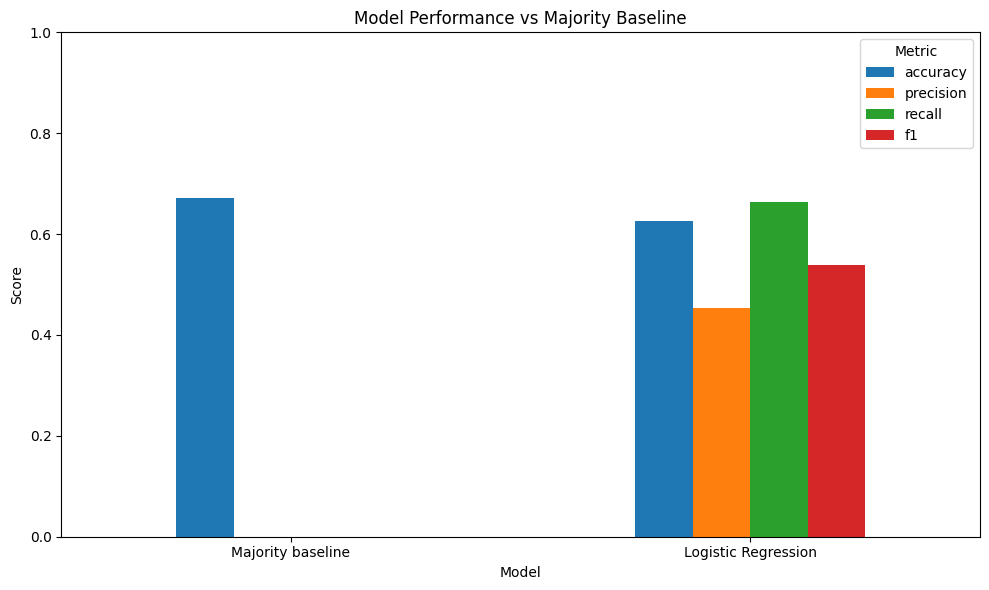

In [60]:
# Chart 1 — Model vs baseline metrics

plot_results = results.copy()

metrics = ["accuracy", "precision", "recall", "f1"]

ax = plot_results.set_index("model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Model Performance vs Majority Baseline")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

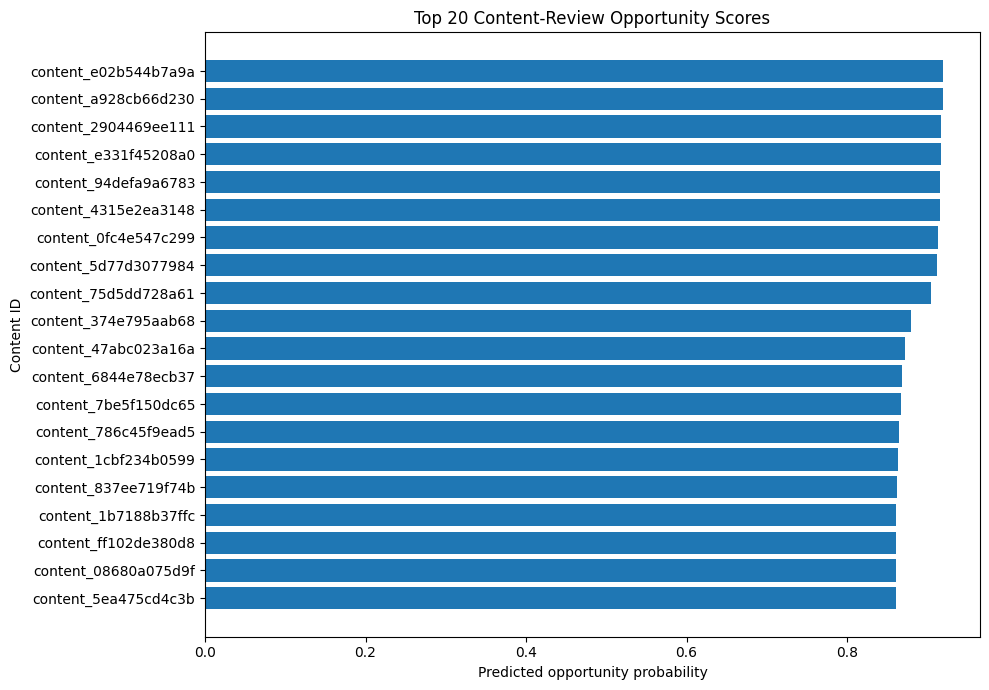

In [61]:
# Chart 2 — Top 20 opportunity scores

top20 = ranked.head(20).sort_values("opportunity_score")

plt.figure(figsize=(10, 7))
plt.barh(
    top20["content_id"],
    top20["opportunity_score"]
)

plt.title("Top 20 Content-Review Opportunity Scores")
plt.xlabel("Predicted opportunity probability")
plt.ylabel("Content ID")
plt.tight_layout()
plt.show()

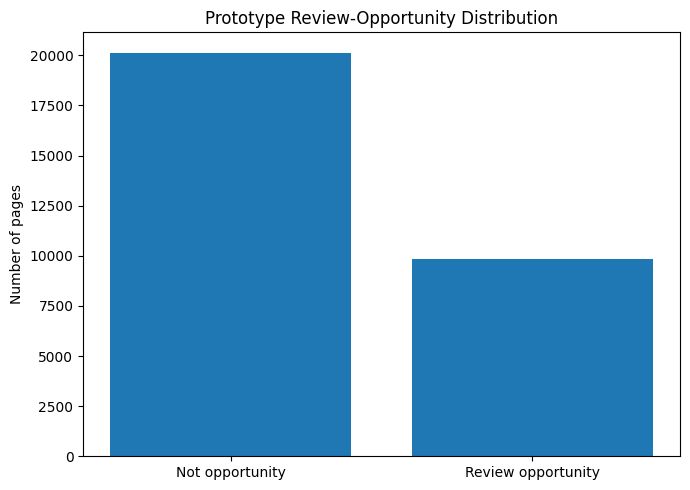

In [62]:
# Chart 3 — Opportunity label distribution

label_counts = df["review_opportunity"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Not opportunity", "Review opportunity"],
    label_counts.values
)

plt.title("Prototype Review-Opportunity Distribution")
plt.ylabel("Number of pages")
plt.tight_layout()
plt.show()

## Data Scope

### Dataset

This capstone uses the public FlyRank starter dataset:

`content_refresh_anonymized.csv`

The starter dataset contains 30,000 rows and 44 columns. It includes anonymized content identifiers and observed search-performance, content, freshness, engagement, and trend fields.

### Time Windows

The dataset provides 90-day aggregate performance fields, last-30-day performance fields, and previous-30-day performance fields.

The starter CSV does not expose a specific calendar release date in the inspected fields, so this analysis does not claim a specific calendar-period release.

### Exclusions

The modeling workflow excludes fields that directly construct the opportunity label, including `impressions_last_30d`, `impressions_prev_30d`, and `recent_impression_change_pct`.

`trend_direction` and `trend_pct` are also excluded because they are closely related to observed performance change.

Client identifiers are not used as predictive features, and the public analysis does not expose client names, domains, private queries, credentials, or raw private exports.

### Public-Safe Framing

The analysis uses anonymized content IDs and aggregate fields from the starter dataset. Results are presented as directional decision-support evidence and are not used to identify clients or claim access to Google's ranking systems.


## Methodology

### Data

The prototype analysis uses the FlyRank anonymized starter dataset containing 30,000 pages and 44 columns. The available data includes search-performance, content, engagement, freshness, and trend-related signals.

Because the full FlyRank Warehouse Dataset was not yet available during this prototype analysis, these results should be treated as development evidence rather than final warehouse results.

### Opportunity Definition

A prototype `review_opportunity` label was created using recent impression change. A page was labeled as an opportunity when it had measurable impressions and its recent 30-day impressions declined at or below the median decline among pages with a measurable decline.

The resulting decline threshold was -36.84%. This produced 9,858 opportunity pages out of 30,000 pages, or 32.84% of the dataset.

This is a transparent prototype definition for testing the workflow; it is not presented as a ground-truth definition of content quality or business value.

### Features

The model used observed content and performance signals including search volume, competition, word count, content age, days since last update, CTR, average position, engagement rate, scroll rate, AI traffic percentage, content type, intent, age tier, freshness tier, word-count tier, character-count tier, impression tier, and position tier.

Variables directly used to construct the prototype target were excluded from the model to reduce leakage. Trend direction and trend percentage were also excluded because they are closely related to performance-change information.

### Validation

The data was divided into an 80/20 stratified train/test split. The training set contained 24,000 rows and the test set contained 6,000 rows. The opportunity rate was approximately 32.9% in both sets.

A majority-class baseline was compared with Logistic Regression using the same untouched test set. Numeric missing values were median-imputed, categorical missing values were filled using the most frequent category, and categorical variables were one-hot encoded.

## Results

On the held-out test set, the majority baseline achieved 0.671 accuracy but did not identify any positive opportunities. Logistic Regression achieved 0.626 accuracy, 0.453 precision, 0.663 recall, 0.538 F1, 0.671 ROC-AUC, and 0.467 PR-AUC.

The model therefore provides a usable prototype ranking signal for identifying review opportunities, while its precision shows that a substantial portion of flagged pages would still require human review.

The model's strongest positive coefficients included keyword-article content type, the 1,000–2,000 word-count tier, low and moderate impression tiers, and some mid-range position tiers. Strong negative coefficients included the top-three position tier, excellent impression tier, and the under-1,000 word-count tier.

The resulting ranking assigns each page an opportunity score and a recommended action category. The top-ranked pages can be used as a starting point for a content team's review queue rather than as automatic editing instructions.


## Limitations and Honest Framing

This analysis has several important limitations.

First, the analysis uses the anonymized starter dataset because the full FlyRank Warehouse Dataset was not yet available during development. The results should therefore be treated as prototype evidence rather than final warehouse findings.

Second, the `review_opportunity` label is a constructed analytical definition based on recent impression decline. It is not a directly observed business outcome and should not be interpreted as proof that a page requires a content refresh.

Third, the Logistic Regression model identifies associations within the available data. The coefficients do not establish that the corresponding signals cause search-performance changes.

Fourth, the model does not reveal or predict Google's ranking algorithm. It also cannot guarantee that editing a recommended page will improve its search performance.

Finally, the ranking should be used as decision support. A human reviewer should consider the page context, search intent, content quality, business importance, and other evidence before taking action.

### Temporal Limitation

The prototype opportunity label is based on the recent 30-day change in impressions, while several available features are aggregated over 90 days. These windows therefore overlap. Direct target fields were excluded from the model, but the remaining 90-day aggregates can still contain information from the target period. For this reason, the model should be interpreted as a cross-sectional ranking prototype rather than a clean future-decline forecasting model.


## Ranked Recommendations

The output creates a prioritized review queue using the model's predicted opportunity probability.

### Priority review

Pages ranked 1–50 should form the initial review queue. Each page is accompanied by reason codes such as recent impression decline, lower CTR, lower impression volume, weaker average position, or lack of recent updates.

### Review queue

Pages ranked 51–200 can form a secondary review queue after the highest-priority pages have been investigated.

### Monitor

Pages ranked 201–1,000 can be monitored for additional evidence before committing review resources.

### Lower priority

Pages outside the first 1,000 positions can remain lower in the review queue unless additional business or editorial evidence changes their priority.

These rankings are prioritization aids, not automatic content-editing instructions.

## Reproducibility

The analysis was developed in Python using Pandas, NumPy, DuckDB, Matplotlib, and scikit-learn.

The capstone notebook and supporting work are maintained in the public GitHub repository:

https://github.com/zeeofficial01/flyrank-ml-internship

The capstone notebook contains the data loading, feature preparation, target construction, train/test split, baseline comparison, Logistic Regression model, evaluation metrics, feature interpretation, opportunity scoring, reason codes, ranking, and visualizations.

## Acknowledgments and Data Credit

Built on the FlyRank ML Internship dataset.

FlyRank: https://flyrank.ai
